In [6]:
import os
import sys
from os import listdir
from os.path import join as opj
import xarray as xr
import dask.dataframe as dd
from matplotlib import pyplot as plt
import re
import pandas as pd
import numpy as np
from ezyrb import POD, RBF
from pydmd import HODMD, ParametricDMD
from scipy.signal import detrend
from scipy.integrate import cumulative_trapezoid
import pdb

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

In [7]:
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

Path2ParquetData = os.path.join(os.path.abspath(""),
                                r'..', r'data', r'parquet_data')

df = dd.read_parquet(os.path.join(Path2ParquetData, "Datalogger.parquet"),
                     engine='pyarrow')
df = df.set_index("Date_Heure", sorted=True)

In [8]:
df = df.map_partitions(lambda df: df.assign(a_r=detrend(df.Capteur_1), 
                                            a_t=detrend(df.Capteur_2)), 
                       meta={"Capteur_1": 'f8', 
                             "Capteur_2": 'f8', 
                             "Temperature": 'f8', 
                             "a_r": 'f8', 
                             "a_t": 'f8'}
                       ).drop("Capteur_1", axis=1).drop("Capteur_2", axis=1)
df = df.map_partitions(lambda df: df.assign(v_r=cumulative_trapezoid(y=df.a_r,
                                                                     dx=0.01,
                                                                     initial=0),
                                            v_t=cumulative_trapezoid(y=df.a_t,
                                                                     dx=0.01,
                                                                     initial=0)),
                       meta={"Temperature": 'f8',
                             "a_r": 'f8',
                             "a_t": 'f8',
                             "v_r": 'f8',
                             "v_t": 'f8',}
                       )

In [9]:
fss = '1s'
rec = 15*60*np.timedelta64(fss.strip('S'), 's').astype(np.int64)
df = df.resample(fss).first().dropna()

/home/kltpk89/.local/anaconda3/envs/socotec/lib/python3.13/site-packages/dask/dataframe/tseries/resample.py:133: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resample = meta_nonempty(self.frame._meta).resample(self.rule, **self.kwargs)


In [10]:
chunk_sizes = list(df.map_partitions(len).compute().values)

da = df[["v_r", "v_t", "Temperature"]].to_dask_array(lengths=chunk_sizes)


da_r = np.stack(
                [b.compute().T for b in da[:, 0].blocks if b.size == rec]
                ).reshape(-1, 1, rec)
da_t = np.stack(
                [b.compute().T for b in da[:, 1].blocks if b.size == rec]
                ).reshape(-1, 1, rec)
T = np.stack(
             [b.mean().compute() for b in da[:, 2].blocks if b.size == rec]
             )

/home/kltpk89/.local/anaconda3/envs/socotec/lib/python3.13/site-packages/dask/dataframe/tseries/resample.py:67: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rule = pd.tseries.frequencies.to_offset(rule)


In [13]:
dmds = [HODMD(svd_rank=0,
              forward_backward=True,
              exact=True,
              opt=True,
              d=1000) for _ in T[:100]]
pdmd = ParametricDMD(dmds,
                     POD(svd_rank=-1),
                     RBF())
pdmd.fit(da_r[:100,:,:],T[:100,])

/home/kltpk89/.local/anaconda3/envs/socotec/lib/python3.13/site-packages/pydmd/paramdmd.py:249: SyntaxWarning: invalid escape sequence '\d'
  """
/home/kltpk89/.local/anaconda3/envs/socotec/lib/python3.13/site-packages/pydmd/paramdmd.py:287: SyntaxWarning: invalid escape sequence '\m'
  """


ValueError: The number of snapshots provided is not enough for d=1000.
Expected at least d.

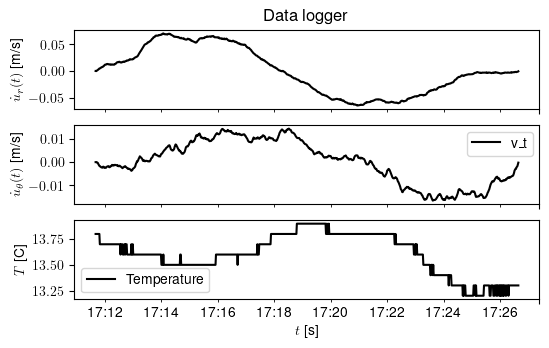

In [23]:
fig, ax = plt.subplots(3, 1,
                       sharex=True,
                       sharey=False,
                       figsize=(6, 3.5))

# average = "1s"
BeginDate = "2016-10-26"
EndDate = "2016-10-26"
PlotDict = {"v_r":"recorded",
            "v_t":"recorded",
            "Temperature":"recorded"}
for i,(k,v) in enumerate(PlotDict.items()):
    
    df.loc[BeginDate:EndDate,[k]].compute().plot(
        ax=ax[i], color='black' )


# l01 = ax[0].plot(dmd_vtm, dmd.reconstructed_data.real[0,:],
#                  color='red',
#                  linewidth=2,
#                  label=r'DMD')


# l11 = ax[1].plot(dmd_vtm, dmd.reconstructed_data.real[1, :],
#                  color='red',
#                  linewidth=2,
#                  label=r'DMD')

ax[0].axis('tight')
ax[0].set(xlabel=r'$t$ [s]',
          ylabel=r'$\dot{u}_r(t)$ [m/s]',
          title='Data logger')
ax[1].axis('tight')
ax[1].set(xlabel=r'$t$ [s]',
          ylabel=r'$\dot{u}_\theta(t)$ [m/s]')
ax[2].axis('tight')
ax[2].set(xlabel=r'$t$ [s]',
          ylabel=r'$T$ [C]')
ax[0].legend('',frameon=False)
# ax[1].legend(frameon=False)
# ax[2].legend(frameon=False)